## Exercise 5: NSE


1) Initialize the NSE solver: `nse_comp = NSESolver()`

2) Calculate the NSE composition for each $\rho$ [g/cm^3], $T$ [GK], $Y_\mathrm{e}$ given in the table: `nse_comp.solve(rho,T,Ye)`

3) Obtain the mass fractions of all nuclei with mass numbers `nse_comp._As` and proton numbers `nse_comp._Zs` using `nse_comp.getMassFractions()`. Check that the NSE solver converged with $\sum{X_i}=1$.

4) Additional functions of the module include:
      `nse_comp.getXn()`, `nse_comp.getXp()`, `nse_comp.getXlight()`, `nse_comp.getXalpha()`, `nse_comp.getXheavy()`
      
      `nse_comp.getAbar()`, `nse_comp.getZbar()`, 
  

In [1]:
import sys
import matplotlib.pyplot as plt
from nse_solver.nse import NSESolver
import numpy as np

In [4]:
nse_comp = NSESolver()

In [52]:
rho = [1e10, 1e11, 1e6, 1e6, 1e6, 1e7, 6.28e9]
temp = [10, 50, 6, 6, 6, 50, 7.26]
Ye = [0.4, 0.3, 0.5, 0.45, 0.65, 0.5, 0.44]

As = []
Zs = []
Xn = []
Xp = []
Xalpha = []
Xlight = []
Xheavy = []
Xi = []
for i in range(0, 7):
    nse_comp.solve(rho[i], temp[i], Ye[i])
    As.append(nse_comp._As)
    Zs.append(nse_comp._Zs)
    Xn.append(nse_comp.getXn())
    Xp.append(nse_comp.getXp())
    Xalpha.append(nse_comp.getXlight())
    Xlight.append(nse_comp.getXalpha())
    Xheavy.append(nse_comp.getXheavy())
    
    Xi = nse_comp.getMassFractions()
    print(sum(Xi)) #convergence check

1.0000042973491465
1.0000000013492598
0.9999999996122865
1.0000020636258693
1.0000000055719525
1.0000050946766297
0.9999959289013127


In [60]:
As[1]

array([  1.,   1.,   2., ..., 335., 336., 337.])

1.0000050946766297


In [42]:
Xn

[0.02864823418761993,
 0.6778697381486479,
 0.006677332033399181,
 0.05118207007245445,
 0.0001422370188504498,
 0.5]

In [43]:
Xp

[3.345826400821542e-05,
 0.27851019526158827,
 0.00755102777587683,
 0.0007203664649759179,
 0.30014223504045356,
 0.5]

In [44]:
Xalpha

[5.858348690044354e-06,
 0.04434130219326952,
 1.1059120633885055e-07,
 8.89648227359313e-08,
 9.22613526597403e-08,
 5.094681279567116e-06]

In [45]:
Xlight

[0.011158669121647497,
 0.001198191146084428,
 0.9759756235028597,
 0.5218625436149908,
 0.6997141722827966,
 2.094197014919398e-15]

In [46]:
Xheavy

[0.9601601445960948,
 1.4855657597971004e-06,
 0.009795906324828284,
 0.4262369991488109,
 1.261759028871434e-06,
 2.46927542475549e-26]

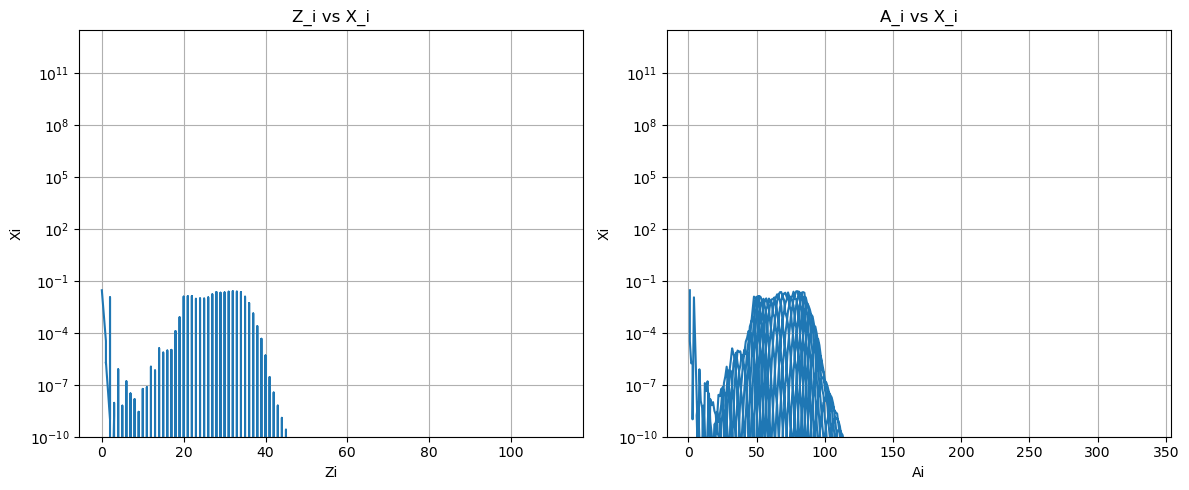

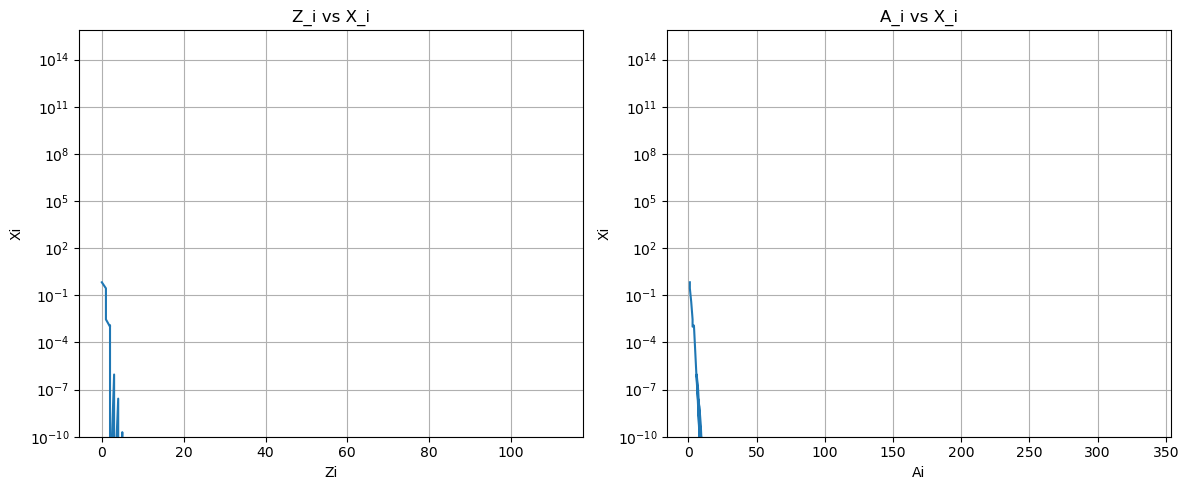

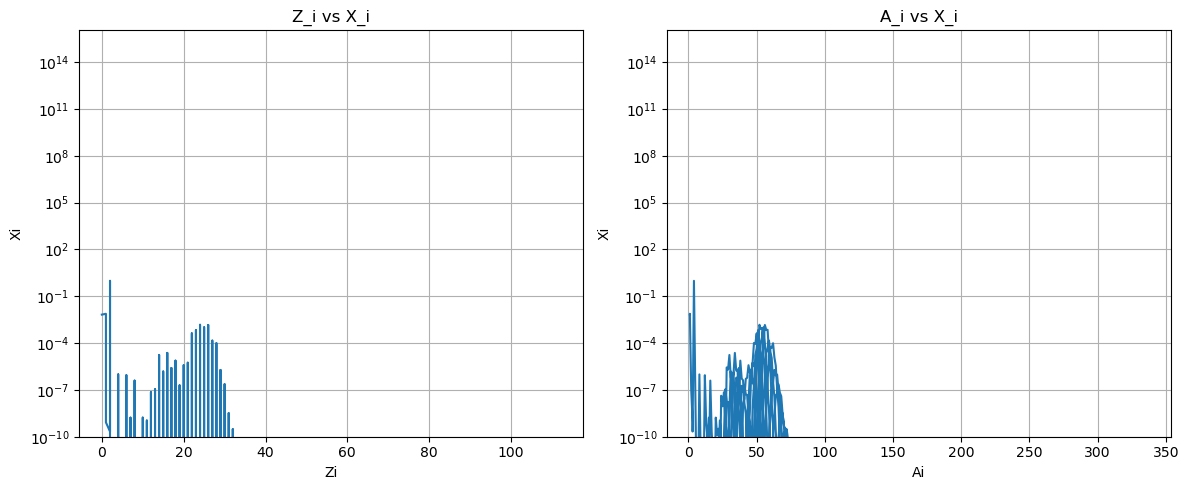

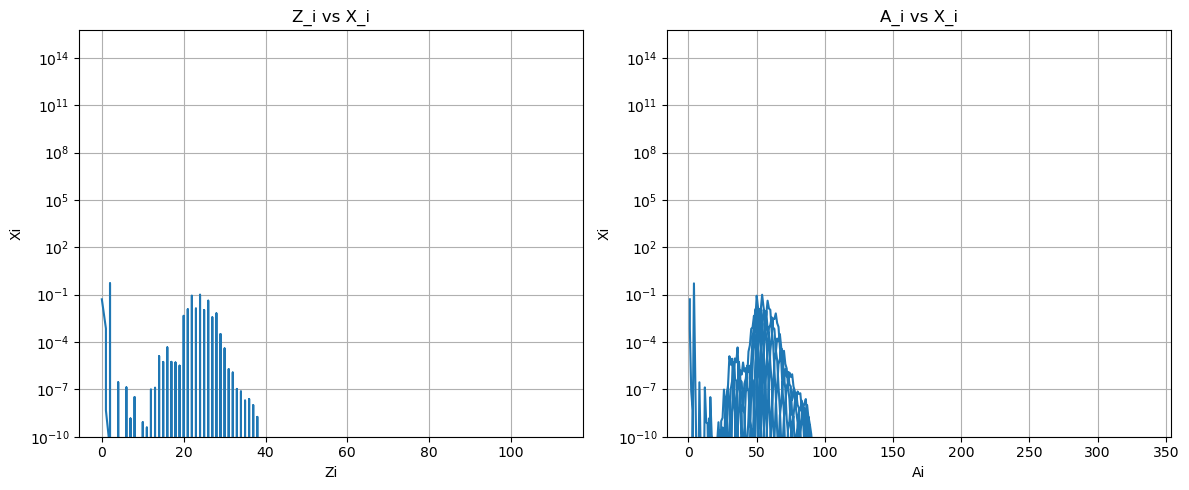

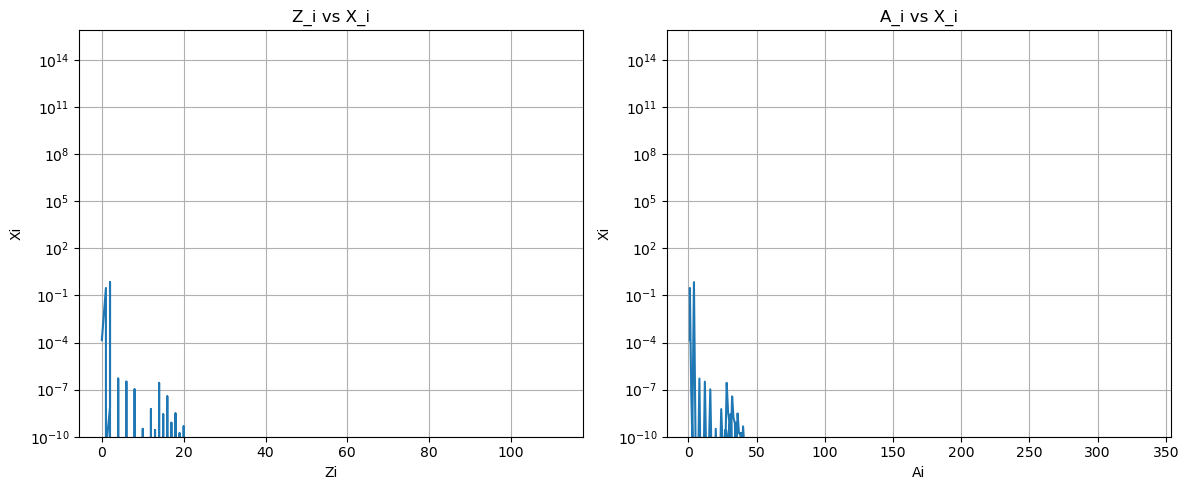

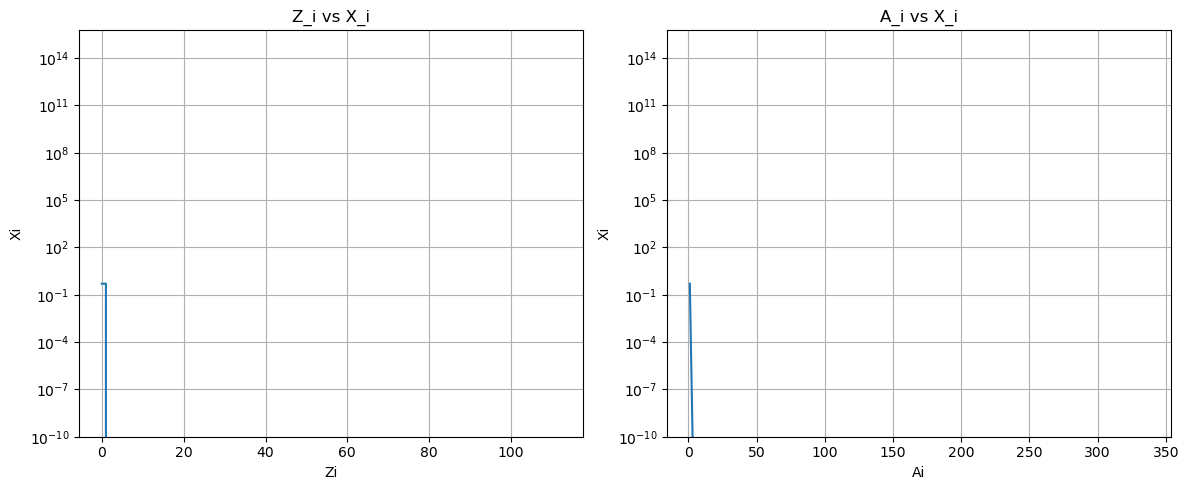

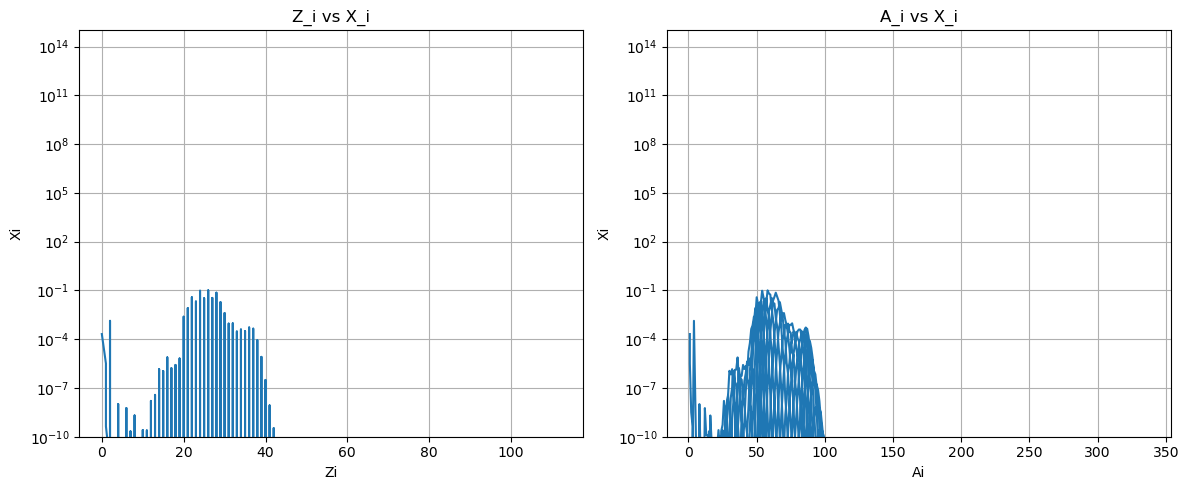

In [58]:
for i in range(0, 7):
    nse_comp.solve(rho[i], temp[i], Ye[i])
    Xi = nse_comp.getMassFractions()
    Ai = nse_comp._As
    Zi = nse_comp._Zs

    for j in Ai: #since Ai = (1, 1, 2, 2, 2, 3, 3, ...) we have to find all the same mass numbers and some those mass fractions
        
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize =(12, 5))
    
    ax1.plot(Zi, Xi, label='Density value {i}')
    ax1.set_title('Z_i vs X_i')
    ax1.set_xlabel('Zi')
    ax1.set_ylabel('Xi')
    ax1.set_yscale("log")
    ax1.set_ylim(bottom = 1e-10)
    ax1.grid(True)

    ax2.plot(Ai, Xi, label='Density value {i}')
    ax2.set_title('A_i vs X_i')
    ax2.set_xlabel('Ai')
    ax2.set_ylabel('Xi')
    ax2.set_yscale("log")
    ax2.set_ylim(bottom = 1e-10)
    ax2.grid(True)

    plt.tight_layout()